# Encoding Categorical Data in Machine Learning

### A complete hands on guide

Machine learning models are mathematical functions. They can only add, multiply and compare **numbers**.
But real world data is full of words: `Male`, `Female`, `Delhi`, `Mumbai`, `B.Tech`, `M.Tech`, `Yes`, `No`.

**Encoding** is the process of converting such categorical (text) data into a numerical form
that a model can actually work with, without destroying the meaning of the data.

---

## What this notebook covers

| # | Topic |
|---|-------|
| 1 | Why do we need encoding at all (with a live error demo) |
| 2 | Types of categorical data: nominal, ordinal, binary, high cardinality, cyclic |
| 3 | Our toy dataset |
| 4 | Label Encoding (from scratch + sklearn) |
| 5 | Ordinal Encoding |
| 6 | One Hot Encoding (internals, dummy trap, sklearn) |
| 7 | Binary Encoding |
| 8 | Frequency and Count Encoding |
| 9 | Target / Mean Encoding (with data leakage and smoothing) |
| 10 | Leave One Out Encoding |
| 11 | Hashing Encoding |
| 12 | Cyclic Encoding for time features |
| 13 | Rare category grouping |
| 14 | Handling unseen categories at test time |
| 15 | Real dataset case study: Titanic + Pipelines |
| 16 | Comparison table and how to choose |
| 17 | Common mistakes |
| 18 | Exercises |

---

## Requirements

```
uv add numpy pandas scikit-learn matplotlib seaborn
```

This notebook only uses standard libraries. No external encoder package is needed,
because we implement every technique from scratch first, and then show the library version.

## 0. Setup

We import everything once here so that later cells stay short and readable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

# Fixing the random seed so that every student gets the same output
np.random.seed(42)

print("numpy version   :", np.__version__)
print("pandas version  :", pd.__version__)

import sklearn
print("sklearn version :", sklearn.__version__)

# Two things in this notebook need a reasonably recent scikit-learn.
# OneHotEncoder(sparse_output=...) needs version 1.2 or higher, older versions call it sparse.
# TargetEncoder in Section 9 needs version 1.3 or higher.
major, minor = [int(v) for v in sklearn.__version__.split('.')[:2]]
if (major, minor) < (1, 3):
    print()
    print("Please upgrade with: uv add --upgrade scikit-learn")

numpy version   : 2.5.2
pandas version  : 3.0.5
sklearn version : 1.9.0


---
# 1. Why do we need encoding?

A model like Linear Regression computes something like:

$$ y = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b $$

If $x_1$ is the string `"Delhi"`, then `w1 * "Delhi"` has no meaning. Multiplication is
simply not defined for text. The same is true for:

* distance based models (KNN, K-Means, SVM) which need `sqrt((x1 - x2)^2 + ...)`
* gradient based models (Neural Networks, Logistic Regression) which need derivatives
* tree based models in scikit-learn, which internally compare `feature <= threshold`

So **every** column that reaches the model must be numeric.

Let us actually watch scikit-learn fail on raw text, so that the need for encoding is felt and not just told.

In [2]:
from sklearn.linear_model import LogisticRegression

# A tiny dataset with one text column
demo = pd.DataFrame({
    'city': ['Delhi', 'Mumbai', 'Delhi', 'Chennai'],
    'bought': [1, 0, 1, 0]
})

try:
    model = LogisticRegression()
    model.fit(demo[['city']], demo['bought'])
except ValueError as err:
    print("scikit-learn refused to train. Error message below")
    print()
    print(err)

scikit-learn refused to train. Error message below

could not convert string to float: 'Delhi'


The error says it could not convert the string to a float. This is exactly the problem encoding solves.

**The goal of encoding is not just to make data numeric. It is to make data numeric in a way that
preserves the information and does not invent information that was never there.**

That second part is the whole reason we have so many different encoding techniques.

---
# 2. Types of categorical data

Before choosing an encoder, you must first identify what kind of category you are dealing with.
This single step decides everything.

| Type | Meaning | Example | Order matters? |
|------|---------|---------|----------------|
| **Nominal** | Pure names, no ranking | City, Colour, Blood group | No |
| **Ordinal** | Categories with a natural order | Education, Rating, Size (S < M < L) | Yes |
| **Binary** | Exactly two categories | Gender, Yes/No, Pass/Fail | Not really |
| **High cardinality** | Very many distinct values | PIN code, Product ID, User ID | No |
| **Cyclic** | Order that wraps around | Month, Hour, Day of week, Wind direction | Yes, circular |

A quick way to inspect this in code is `nunique()` and `value_counts()`.

In [3]:
# A helper we will reuse to inspect any categorical column
def describe_categorical(df, column):
    print("Column        :", column)
    print("Data type     :", df[column].dtype)
    print("Unique values :", df[column].nunique())
    print("Categories    :", list(df[column].unique()))
    print()
    print(df[column].value_counts())

---
# 3. Our toy dataset

We start with a very small dataset that fits on one screen. This is deliberate.
When the data is small you can verify the encoded output **by hand**, which is how you truly
understand what an encoder is doing internally.

Later, in Section 15, we move to a real standard dataset (Titanic).

In [4]:
data = {
    'city':      ['Delhi', 'Mumbai', 'Delhi', 'Chennai', 'Mumbai', 'Delhi',
                  'Kolkata', 'Chennai', 'Delhi', 'Mumbai', 'Kolkata', 'Delhi'],
    'education': ['Bachelors', 'Masters', 'High School', 'PhD', 'Bachelors', 'Masters',
                  'High School', 'Bachelors', 'PhD', 'Masters', 'Bachelors', 'High School'],
    'gender':    ['Male', 'Female', 'Female', 'Male', 'Male', 'Female',
                  'Male', 'Female', 'Male', 'Female', 'Male', 'Female'],
    'month':     [1, 3, 5, 7, 9, 11, 12, 2, 4, 6, 8, 10],
    'salary':    [50000, 82000, 31000, 120000, 47000, 91000,
                  28000, 55000, 130000, 88000, 42000, 33000],
    'bought':    [0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0]
}

df = pd.DataFrame(data)
df

,city,education,gender,month,salary,bought
0,Delhi,Bachelors,Male,1,50000,0
1,Mumbai,Masters,Female,3,82000,1
2,Delhi,High School,Female,5,31000,0
3,Chennai,PhD,Male,7,120000,1
4,Mumbai,Bachelors,Male,9,47000,0
5,Delhi,Masters,Female,11,91000,1
6,Kolkata,High School,Male,12,28000,0
7,Chennai,Bachelors,Female,2,55000,0
8,Delhi,PhD,Male,4,130000,1
9,Mumbai,Masters,Female,6,88000,1


In [5]:
# city is nominal, there is no natural ranking between Delhi and Mumbai
describe_categorical(df, 'city')

Column        : city
Data type     : str
Unique values : 4
Categories    : ['Delhi', 'Mumbai', 'Chennai', 'Kolkata']

city
Delhi      5
Mumbai     3
Chennai    2
Kolkata    2
Name: count, dtype: int64


In [6]:
# education is ordinal, High School < Bachelors < Masters < PhD
describe_categorical(df, 'education')

Column        : education
Data type     : str
Unique values : 4
Categories    : ['Bachelors', 'Masters', 'High School', 'PhD']

education
Bachelors      4
Masters        3
High School    3
PhD            2
Name: count, dtype: int64


---
# 4. Label Encoding

**Idea:** sort the unique categories, then give each one an integer starting from 0.

```
Chennai -> 0
Delhi   -> 1
Kolkata -> 2
Mumbai  -> 3
```

## 4.1 How it works internally

The algorithm is just three steps:

1. Collect the unique values of the column
2. Sort them (scikit-learn sorts alphabetically so the result is reproducible)
3. Build a dictionary `category -> index` and map the column through it

Let us write it ourselves before using the library.

In [7]:
def label_encode_from_scratch(series):
    # Step 1 and 2, unique values in sorted order
    categories = sorted(series.unique())

    # Step 3, build the lookup dictionary
    mapping = {category: index for index, category in enumerate(categories)}

    # Apply the dictionary to every row
    encoded = series.map(mapping)

    return encoded, mapping


city_encoded, city_mapping = label_encode_from_scratch(df['city'])

print("Mapping learned:", city_mapping)
print()
pd.DataFrame({'original': df['city'], 'label_encoded': city_encoded})

Mapping learned: {'Chennai': 0, 'Delhi': 1, 'Kolkata': 2, 'Mumbai': 3}



,original,label_encoded
0,Delhi,1
1,Mumbai,3
2,Delhi,1
3,Chennai,0
4,Mumbai,3
5,Delhi,1
6,Kolkata,2
7,Chennai,0
8,Delhi,1
9,Mumbai,3


## 4.2 The scikit-learn version

`LabelEncoder` does exactly the same thing. Note that it is designed for a **single column**,
and officially it is meant for encoding the **target variable** `y`, not the input features.

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
sklearn_result = le.fit_transform(df['city'])

print("Classes found by sklearn :", le.classes_)
print("Encoded values           :", sklearn_result)

# Comparing our from scratch result with sklearn
print("Same as our version      :", np.array_equal(sklearn_result, city_encoded.values))

Classes found by sklearn : ['Chennai' 'Delhi' 'Kolkata' 'Mumbai']
Encoded values           : [1 3 1 0 3 1 2 0 1 3 2 1]
Same as our version      : True


In [9]:
# inverse_transform converts the numbers back to the original labels
print(le.inverse_transform([0, 1, 2, 3]))

['Chennai' 'Delhi' 'Kolkata' 'Mumbai']


## 4.3 The big problem with Label Encoding

Look at what the model now sees:

```
Chennai = 0,  Delhi = 1,  Kolkata = 2,  Mumbai = 3
```

A linear model will happily conclude that

* `Mumbai > Delhi` because `3 > 1`
* `Delhi` is exactly halfway between `Chennai` and `Kolkata` because `(0 + 2) / 2 = 1`
* `Mumbai` is three times `Delhi`

None of this is true. We have **injected a fake ordering** into nominal data. This is called
the *false ordinality* problem and it can seriously mislead linear models, KNN, SVM and neural networks.

**When is label encoding acceptable?**

* For the **target column** `y` in a classification problem
* For **ordinal** features, but only if the sorted order happens to match the real order
* For **tree based models** (Decision Tree, Random Forest, XGBoost), because a tree splits on
  `feature <= threshold` and can carve out any group with enough splits, so the fake order hurts far less

---
# 5. Ordinal Encoding

**Idea:** same as label encoding, but **you** decide the order instead of the alphabet.

This is the correct choice when the categories genuinely have a ranking:

```
High School (0)  <  Bachelors (1)  <  Masters (2)  <  PhD (3)
```

Here the numbers carry real meaning. The gap between them is now informative,
so a model is allowed to use `education > 1`.

In [10]:
# Notice what plain label encoding would do to education
print("Alphabetical order sklearn would use:", sorted(df['education'].unique()))
print("This gives Bachelors=0, High School=1 which is WRONG, a Bachelors degree is higher")

Alphabetical order sklearn would use: ['Bachelors', 'High School', 'Masters', 'PhD']
This gives Bachelors=0, High School=1 which is WRONG, a Bachelors degree is higher


In [11]:
# The manual pandas way, define the order explicitly
education_order = {
    'High School': 0,
    'Bachelors': 1,
    'Masters': 2,
    'PhD': 3
}

df['education_ordinal'] = df['education'].map(education_order)
df[['education', 'education_ordinal']]

,education,education_ordinal
0,Bachelors,1
1,Masters,2
2,High School,0
3,PhD,3
4,Bachelors,1
5,Masters,2
6,High School,0
7,Bachelors,1
8,PhD,3
9,Masters,2


## 5.1 The scikit-learn version

`OrdinalEncoder` works on a 2D input (a DataFrame or 2D array), so it can handle
several columns at once. Pass the `categories` argument to control the order.

In [12]:
from sklearn.preprocessing import OrdinalEncoder

# The order inside the list is the order that will be used, first item becomes 0
ordinal_enc = OrdinalEncoder(categories=[['High School', 'Bachelors', 'Masters', 'PhD']])

result = ordinal_enc.fit_transform(df[['education']])

pd.DataFrame({
    'original': df['education'],
    'ordinal_encoded': result.ravel()
})

,original,ordinal_encoded
0,Bachelors,1.0
1,Masters,2.0
2,High School,0.0
3,PhD,3.0
4,Bachelors,1.0
5,Masters,2.0
6,High School,0.0
7,Bachelors,1.0
8,PhD,3.0
9,Masters,2.0


## 5.2 Handling categories not seen during training

If a new category appears in the test set, the encoder will raise an error by default.
`handle_unknown='use_encoded_value'` lets you assign a fallback number such as `-1`.

In [13]:
enc = OrdinalEncoder(
    categories=[['High School', 'Bachelors', 'Masters', 'PhD']],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
enc.fit(df[['education']])

# Diploma was never present in the training data
test_data = pd.DataFrame({'education': ['Masters', 'Diploma', 'PhD']})
print(enc.transform(test_data))

[[ 2.]
 [-1.]
 [ 3.]]


---
# 6. One Hot Encoding

This is the most widely used encoder for **nominal** data and the one your course starts with.

**Idea:** create one new binary column for every category. Put a `1` in the column matching the
row's category and `0` everywhere else.

```
city                Delhi  Mumbai  Chennai  Kolkata
Delhi      ->         1       0       0        0
Mumbai     ->         0       1       0        0
Chennai    ->         0       0       1        0
```

Now no category is greater than another. All of them are at the same distance from each other,
which is exactly what "nominal" means.

## 6.1 The internal mathematics

One hot encoding is nothing but **indexing the rows of an identity matrix**.

If there are `k` categories, build the `k x k` identity matrix $I_k$. A category with index `i`
is represented by row `i` of $I_k$.

For 4 cities:

$$ I_4 = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix} $$

So internally the library does: **label encode first, then pick that row of the identity matrix.**

In [14]:
def one_hot_from_scratch(series):
    # Step 1, label encode to get an integer index for each row
    categories = sorted(series.unique())
    mapping = {category: index for index, category in enumerate(categories)}
    indices = series.map(mapping).values

    # Step 2, build the identity matrix of size k by k
    k = len(categories)
    identity = np.eye(k, dtype=int)

    # Step 3, pick the row of the identity matrix for every sample
    encoded_matrix = identity[indices]

    # Wrap it in a DataFrame with readable column names
    column_names = [series.name + '_' + str(c) for c in categories]
    return pd.DataFrame(encoded_matrix, columns=column_names, index=series.index)


ohe_manual = one_hot_from_scratch(df['city'])
pd.concat([df[['city']], ohe_manual], axis=1)

,city,city_Chennai,city_Delhi,city_Kolkata,city_Mumbai
0,Delhi,0,1,0,0
1,Mumbai,0,0,0,1
2,Delhi,0,1,0,0
3,Chennai,1,0,0,0
4,Mumbai,0,0,0,1
5,Delhi,0,1,0,0
6,Kolkata,0,0,1,0
7,Chennai,1,0,0,0
8,Delhi,0,1,0,0
9,Mumbai,0,0,0,1


In [15]:
# Seeing the identity matrix trick clearly
print("Identity matrix for 4 categories")
print(np.eye(4, dtype=int))
print()
print("Row 1 of this matrix is the code for Delhi:", np.eye(4, dtype=int)[1])

Identity matrix for 4 categories
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]

Row 1 of this matrix is the code for Delhi: [0 1 0 0]


## 6.2 The pandas way: `pd.get_dummies`

For quick exploration this is the fastest method.

In [16]:
dummies = pd.get_dummies(df['city'], prefix='city', dtype=int)
pd.concat([df[['city']], dummies], axis=1)

,city,city_Chennai,city_Delhi,city_Kolkata,city_Mumbai
0,Delhi,0,1,0,0
1,Mumbai,0,0,0,1
2,Delhi,0,1,0,0
3,Chennai,1,0,0,0
4,Mumbai,0,0,0,1
5,Delhi,0,1,0,0
6,Kolkata,0,0,1,0
7,Chennai,1,0,0,0
8,Delhi,0,1,0,0
9,Mumbai,0,0,0,1


In [17]:
# get_dummies can encode several columns in one call
pd.get_dummies(df[['city', 'gender']], dtype=int)

,city_Chennai,city_Delhi,city_Kolkata,city_Mumbai,gender_Female,gender_Male
0,0,1,0,0,0,1
1,0,0,0,1,1,0
2,0,1,0,0,1,0
3,1,0,0,0,0,1
4,0,0,0,1,0,1
5,0,1,0,0,1,0
6,0,0,1,0,0,1
7,1,0,0,0,1,0
8,0,1,0,0,0,1
9,0,0,0,1,1,0


## 6.3 The scikit-learn way: `OneHotEncoder`

`pd.get_dummies` is convenient but it has one serious weakness: it does not remember the
categories it saw during training. If the test set is missing a city, you get a different
number of columns and the model breaks.

`OneHotEncoder` **learns** the categories in `fit()` and reuses them in `transform()`.
This is why production code always uses it.

In [18]:
from sklearn.preprocessing import OneHotEncoder

# sparse_output=False returns a normal dense numpy array, easier to read while learning
ohe = OneHotEncoder(sparse_output=False, dtype=int)

encoded = ohe.fit_transform(df[['city']])

print("Categories remembered :", ohe.categories_)
print("Output shape          :", encoded.shape)
print()
pd.DataFrame(encoded, columns=ohe.get_feature_names_out())

Categories remembered : [array(['Chennai', 'Delhi', 'Kolkata', 'Mumbai'], dtype=object)]
Output shape          : (12, 4)



,city_Chennai,city_Delhi,city_Kolkata,city_Mumbai
0,0,1,0,0
1,0,0,0,1
2,0,1,0,0
3,1,0,0,0
4,0,0,0,1
5,0,1,0,0
6,0,0,1,0
7,1,0,0,0
8,0,1,0,0
9,0,0,0,1


## 6.4 The dummy variable trap

Look carefully at the four city columns. If you know three of them, the fourth is fully determined:

```
Kolkata = 1 - Delhi - Mumbai - Chennai
```

The columns are **linearly dependent**. This is called *multicollinearity* or the
**dummy variable trap**. For Linear and Logistic Regression it makes the matrix
$X^T X$ singular, so the coefficients become unstable and hard to interpret.

The fix is to drop one column. The dropped category becomes the **reference** or **baseline** category.
`k` categories then need only `k - 1` columns. This is technically called **dummy encoding**.

> **Rule of thumb:** drop one column for linear models (Linear Regression, Logistic Regression).
> Keep all columns for tree based models and neural networks, which are not affected by collinearity.

In [19]:
# scikit-learn version, drop='first' removes the alphabetically first category
ohe_drop = OneHotEncoder(sparse_output=False, drop='first', dtype=int)
encoded_drop = ohe_drop.fit_transform(df[['city']])

print("Baseline category that was dropped:", ohe_drop.categories_[0][0])
print()
pd.DataFrame(encoded_drop, columns=ohe_drop.get_feature_names_out())

Baseline category that was dropped: Chennai



,city_Delhi,city_Kolkata,city_Mumbai
0,1,0,0
1,0,0,1
2,1,0,0
3,0,0,0
4,0,0,1
5,1,0,0
6,0,1,0
7,0,0,0
8,1,0,0
9,0,0,1


In [20]:
# pandas version, drop_first=True
pd.get_dummies(df['city'], prefix='city', drop_first=True, dtype=int)

,city_Delhi,city_Kolkata,city_Mumbai
0,1,0,0
1,0,0,1
2,1,0,0
3,0,0,0
4,0,0,1
5,1,0,0
6,0,1,0
7,0,0,0
8,1,0,0
9,0,0,1


## 6.5 The main limitation: dimensionality explosion

One hot encoding creates one column per category. If a column has 5000 unique product IDs,
you get 5000 new columns, almost all of them zero. This causes

* huge memory usage
* very slow training
* the *curse of dimensionality*, distances become meaningless
* trees perform badly because each individual dummy column carries very little information

Let us measure this growth.

In [21]:
# Simulating columns with increasing number of categories
for n_categories in [5, 50, 500, 5000]:
    fake = pd.Series(['cat_' + str(i) for i in range(n_categories)] * 2)
    encoded = pd.get_dummies(fake, dtype=np.int8)
    memory_mb = encoded.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"{n_categories:>5} categories  ->  {encoded.shape[1]:>5} columns, "
          f"{memory_mb:8.3f} MB, sparsity {100 * (1 - 1 / n_categories):.2f} percent zeros")

    5 categories  ->      5 columns,    0.000 MB, sparsity 80.00 percent zeros
   50 categories  ->     50 columns,    0.005 MB, sparsity 98.00 percent zeros
  500 categories  ->    500 columns,    0.477 MB, sparsity 99.80 percent zeros
 5000 categories  ->   5000 columns,   47.684 MB, sparsity 99.98 percent zeros


### Sparse matrices

Since almost every value is zero, scikit-learn stores the result as a **sparse matrix** by default.
A sparse matrix only stores the positions of the non zero entries, which saves an enormous amount of memory.

In [22]:
big = pd.DataFrame({'code': ['code_' + str(i % 1000) for i in range(5000)]})

dense = OneHotEncoder(sparse_output=False).fit_transform(big[['code']])
sparse = OneHotEncoder(sparse_output=True).fit_transform(big[['code']])

print("Dense  storage :", dense.nbytes / (1024 ** 2), "MB")
print("Sparse storage :", (sparse.data.nbytes + sparse.indices.nbytes + sparse.indptr.nbytes) / (1024 ** 2), "MB")
print("Sparse type    :", type(sparse))

Dense  storage : 38.14697265625 MB
Sparse storage : 0.07629776000976562 MB
Sparse type    : <class 'scipy.sparse._csr.csr_matrix'>


---
# 7. Binary Encoding

**Idea:** label encode first, then write that integer in **binary**, and give every bit its own column.

```
Delhi   -> 1 -> 001
Kolkata -> 2 -> 010
Mumbai  -> 3 -> 011
Chennai -> 0 -> 000
```

Why is this useful? For `k` categories one hot needs `k` columns, but binary encoding needs
only $\lceil \log_2 k \rceil$ columns.

| Categories | One hot columns | Binary columns |
|-----------|-----------------|----------------|
| 4 | 4 | 2 |
| 100 | 100 | 7 |
| 1000 | 1000 | 10 |
| 10000 | 10000 | 14 |

This is the standard compromise for **high cardinality nominal** data. The trade off is that the
columns are no longer directly interpretable, and two unrelated categories may share bits.

In [23]:
def binary_encode_from_scratch(series):
    # Step 1, label encode, starting from 1 so that no category becomes all zeros
    categories = sorted(series.unique())
    mapping = {category: index + 1 for index, category in enumerate(categories)}
    integers = series.map(mapping)

    # Step 2, find how many bits are needed
    n_bits = int(np.ceil(np.log2(len(categories) + 1)))

    # Step 3, extract each bit into its own column using bit shifting
    out = {}
    for bit in range(n_bits):
        column_name = series.name + '_bit' + str(bit)
        out[column_name] = (integers.values >> bit) & 1

    # Reversing so that the most significant bit appears first, purely for readability
    frame = pd.DataFrame(out, index=series.index)
    return frame[frame.columns[::-1]], mapping


binary_df, binary_map = binary_encode_from_scratch(df['city'])

print("Integer assigned to each city:", binary_map)
print()
pd.concat([df[['city']], binary_df], axis=1)

Integer assigned to each city: {'Chennai': 1, 'Delhi': 2, 'Kolkata': 3, 'Mumbai': 4}



,city,city_bit2,city_bit1,city_bit0
0,Delhi,0,1,0
1,Mumbai,1,0,0
2,Delhi,0,1,0
3,Chennai,0,0,1
4,Mumbai,1,0,0
5,Delhi,0,1,0
6,Kolkata,0,1,1
7,Chennai,0,0,1
8,Delhi,0,1,0
9,Mumbai,1,0,0


In [24]:
# Comparing the width of the two encodings as cardinality grows
sizes = [4, 10, 50, 100, 1000, 10000]
comparison = pd.DataFrame({
    'n_categories': sizes,
    'one_hot_columns': sizes,
    'binary_columns': [int(np.ceil(np.log2(n + 1))) for n in sizes]
})
comparison['reduction_percent'] = (
    100 * (1 - comparison['binary_columns'] / comparison['one_hot_columns'])
).round(2)
comparison

,n_categories,one_hot_columns,binary_columns,reduction_percent
0,4,4,3,25.00
1,10,10,4,60.00
2,50,50,6,88.00
3,100,100,7,93.00
4,1000,1000,10,99.00
5,10000,10000,14,99.86


---
# 8. Frequency and Count Encoding

**Idea:** replace each category by how often it appears in the data.

* **Count encoding** uses the raw number of occurrences
* **Frequency encoding** uses the proportion, that is count divided by total rows

This always produces exactly **one** column no matter how many categories exist, which makes it
excellent for high cardinality features. It is very popular in Kaggle competitions with tree models.

The assumption is that *how common a category is* carries useful signal. For example, a rare
PIN code might behave differently from a very common one.

In [25]:
def frequency_encode(series, normalize=True):
    # value_counts gives the number of times each category appears
    counts = series.value_counts(normalize=normalize)
    return series.map(counts), counts


freq_values, freq_map = frequency_encode(df['city'], normalize=True)
count_values, count_map = frequency_encode(df['city'], normalize=False)

print("Frequency map")
print(freq_map)
print()

pd.DataFrame({
    'city': df['city'],
    'count_encoded': count_values,
    'frequency_encoded': freq_values.round(4)
})

Frequency map
city
Delhi      0.416667
Mumbai     0.250000
Chennai    0.166667
Kolkata    0.166667
Name: proportion, dtype: float64



,city,count_encoded,frequency_encoded
0,Delhi,5,0.4167
1,Mumbai,3,0.2500
2,Delhi,5,0.4167
3,Chennai,2,0.1667
4,Mumbai,3,0.2500
5,Delhi,5,0.4167
6,Kolkata,2,0.1667
7,Chennai,2,0.1667
8,Delhi,5,0.4167
9,Mumbai,3,0.2500


**Warning about collisions:** if two categories appear the same number of times, they receive the
same number and the model can no longer tell them apart. Above, `Chennai` and `Kolkata` both
appear twice, so both become `0.1667`. With large datasets this is rare, but you should be aware of it.

---
# 9. Target Encoding (also called Mean Encoding)

**Idea:** replace each category by the **mean value of the target** for that category.

For a binary target this becomes the probability of class 1 given the category:

$$ \text{encoding}(c) = \frac{\sum_{i : x_i = c} y_i}{n_c} = P(y = 1 \mid x = c) $$

This is extremely powerful because the encoded number is directly related to what we are
predicting. It produces one column regardless of cardinality.

It is also the **most dangerous** encoder in this notebook, because it uses the target,
and using the target carelessly causes **data leakage** and **overfitting**.

In [26]:
def target_encode_simple(series, target):
    # Group the target by category and take the mean
    means = target.groupby(series).mean()
    return series.map(means), means


te_values, te_map = target_encode_simple(df['city'], df['bought'])

print("Mean of target for each city")
print(te_map)
print()

pd.DataFrame({
    'city': df['city'],
    'bought': df['bought'],
    'target_encoded': te_values.round(4)
})

Mean of target for each city
city
Chennai    0.500000
Delhi      0.400000
Kolkata    0.000000
Mumbai     0.666667
Name: bought, dtype: float64



,city,bought,target_encoded
0,Delhi,0,0.4000
1,Mumbai,1,0.6667
2,Delhi,0,0.4000
3,Chennai,1,0.5000
4,Mumbai,0,0.6667
5,Delhi,1,0.4000
6,Kolkata,0,0.0000
7,Chennai,0,0.5000
8,Delhi,1,0.4000
9,Mumbai,1,0.6667


## 9.1 Problem 1: rare categories give unreliable estimates

If a category appears only once and that row happens to have `y = 1`, its encoding becomes `1.0`.
The model then treats that category as a perfect predictor, which is pure noise.

## 9.2 The solution: smoothing

We blend the category mean with the **global mean** of the target. Categories with many samples
keep their own mean, categories with few samples get pulled toward the global mean.

$$ \text{encoding}(c) = \frac{n_c \cdot \bar{y}_c + m \cdot \bar{y}_{global}}{n_c + m} $$

where

* $n_c$ is the number of rows in category `c`
* $\bar{y}_c$ is the target mean of category `c`
* $\bar{y}_{global}$ is the overall target mean
* $m$ is the smoothing strength you choose, larger `m` means more shrinkage

In [27]:
def target_encode_smooth(series, target, m=2.0):
    global_mean = target.mean()

    stats = target.groupby(series).agg(['mean', 'count'])
    stats.columns = ['category_mean', 'n']

    # The smoothing formula, a weighted average of category mean and global mean
    stats['smoothed'] = (
        (stats['n'] * stats['category_mean'] + m * global_mean) / (stats['n'] + m)
    )

    return series.map(stats['smoothed']), stats


smoothed_values, stats = target_encode_smooth(df['city'], df['bought'], m=2.0)

print("Global target mean:", round(df['bought'].mean(), 4))
print()
stats.round(4)

Global target mean: 0.4167



,category_mean,n,smoothed
city,,,
Chennai,0.5000,2,0.4583
Delhi,0.4000,5,0.4048
Kolkata,0.0000,2,0.2083
Mumbai,0.6667,3,0.5667


In [28]:
# Watching the effect of the smoothing strength m
for m in [0, 1, 5, 20]:
    _, s = target_encode_smooth(df['city'], df['bought'], m=m)
    print(f"m = {m:>2} ->", dict(s['smoothed'].round(3)))

m =  0 -> {'Chennai': np.float64(0.5), 'Delhi': np.float64(0.4), 'Kolkata': np.float64(0.0), 'Mumbai': np.float64(0.667)}
m =  1 -> {'Chennai': np.float64(0.472), 'Delhi': np.float64(0.403), 'Kolkata': np.float64(0.139), 'Mumbai': np.float64(0.604)}
m =  5 -> {'Chennai': np.float64(0.44), 'Delhi': np.float64(0.408), 'Kolkata': np.float64(0.298), 'Mumbai': np.float64(0.51)}
m = 20 -> {'Chennai': np.float64(0.424), 'Delhi': np.float64(0.413), 'Kolkata': np.float64(0.379), 'Mumbai': np.float64(0.449)}


Notice how a larger `m` pushes every category toward the global mean of `0.4167`.
With `m = 0` you get the raw, unsmoothed means.

## 9.3 Problem 2: data leakage

If you compute a row's encoding using that row's own target value, you have leaked the answer
into the feature. Training accuracy shoots up and test accuracy collapses.

**Correct practice:**

1. Fit the encoder on the **training set only**, then apply it to the test set
2. Inside the training set, use **K-Fold** or **leave one out** so that a row is never encoded using its own target

In [29]:
from sklearn.model_selection import KFold

def kfold_target_encode(series, target, n_splits=4, m=2.0):
    # Encoding for each fold is computed from the OTHER folds only
    encoded = pd.Series(index=series.index, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_index, valid_index in kf.split(series):
        train_series = series.iloc[train_index]
        train_target = target.iloc[train_index]

        global_mean = train_target.mean()
        stats = train_target.groupby(train_series).agg(['mean', 'count'])
        smoothed = (stats['count'] * stats['mean'] + m * global_mean) / (stats['count'] + m)

        # Categories missing from this fold fall back to the global mean
        encoded.iloc[valid_index] = series.iloc[valid_index].map(smoothed).fillna(global_mean).values

    return encoded


kfold_values = kfold_target_encode(df['city'], df['bought'])

pd.DataFrame({
    'city': df['city'],
    'bought': df['bought'],
    'leaky_encoding': te_values.round(3),
    'kfold_encoding': kfold_values.round(3)
})

,city,bought,leaky_encoding,kfold_encoding
0,Delhi,0,0.400,0.481
1,Mumbai,1,0.667,0.630
2,Delhi,0,0.400,0.167
3,Chennai,1,0.500,0.444
4,Mumbai,0,0.667,0.630
5,Delhi,1,0.400,0.167
6,Kolkata,0,0.000,0.296
7,Chennai,0,0.500,0.444
8,Delhi,1,0.400,0.167
9,Mumbai,1,0.667,0.472


Look at the two right hand columns. The leaky version gives the same number to every row of the
same city. The K-Fold version gives slightly different numbers, because each row was encoded
without looking at itself. That small amount of noise is what protects you from overfitting.

## 9.4 The scikit-learn version

Since version 1.3, scikit-learn ships `TargetEncoder`, which performs cross fitted target encoding
automatically when you call `fit_transform`.

In [30]:
from sklearn.preprocessing import TargetEncoder

te = TargetEncoder(smooth='auto', random_state=42)

# fit_transform uses internal cross fitting, which is the leakage safe path
encoded_train = te.fit_transform(df[['city']], df['bought'])

pd.DataFrame({
    'city': df['city'],
    'bought': df['bought'],
    'sklearn_target_encoded': encoded_train.ravel().round(4)
})

c:\Users\Tavneet\Documents\ml_lab_practicals_csp_dc_305\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


,city,bought,sklearn_target_encoded
0,Delhi,0,0.4813
1,Mumbai,1,1.0000
2,Delhi,0,0.4813
3,Chennai,1,0.0000
4,Mumbai,0,1.0000
5,Delhi,1,0.2745
6,Kolkata,0,0.4444
7,Chennai,0,1.0000
8,Delhi,1,0.4813
9,Mumbai,1,0.4658


---
# 10. Leave One Out Encoding

This is target encoding taken to its extreme. For each row, the encoding is the mean of the target
over all **other** rows of the same category:

$$ \text{encoding}(x_i) = \frac{\left(\sum_{j : x_j = x_i} y_j\right) - y_i}{n_c - 1} $$

Because the row's own target is subtracted out, leakage for that row is removed directly.
It is simple and effective, but still needs care, and it fails when a category has only one row.

In [31]:
def leave_one_out_encode(series, target):
    grouped = target.groupby(series)
    category_sum = series.map(grouped.sum())
    category_count = series.map(grouped.count())

    # Remove the current row from both the numerator and the denominator
    numerator = category_sum - target
    denominator = category_count - 1

    # If a category has only one row, fall back to the global mean
    result = numerator / denominator.replace(0, np.nan)
    return result.fillna(target.mean())


loo = leave_one_out_encode(df['city'], df['bought'])

pd.DataFrame({
    'city': df['city'],
    'bought': df['bought'],
    'leave_one_out': loo.round(3)
})

,city,bought,leave_one_out
0,Delhi,0,0.50
1,Mumbai,1,0.50
2,Delhi,0,0.50
3,Chennai,1,0.00
4,Mumbai,0,1.00
5,Delhi,1,0.25
6,Kolkata,0,0.00
7,Chennai,0,1.00
8,Delhi,1,0.25
9,Mumbai,1,0.50


---
# 11. Hashing Encoding (the Hashing Trick)

**Idea:** pass the category through a hash function and take the remainder with a fixed
number of output columns `n`.

$$ \text{column index} = \text{hash}(\text{category}) \bmod n $$

Properties:

* You decide the output size in advance, it never grows
* **No fitting is needed**, there is no dictionary to store, so memory use is constant
* It handles categories that were never seen before, including at prediction time
* Perfect for streaming data and for millions of categories

The cost is **collisions**: two different categories can land in the same column, and you cannot
reverse the encoding to recover the original category.

In [32]:
from sklearn.feature_extraction import FeatureHasher

# n_features is the fixed number of output columns you choose
hasher = FeatureHasher(n_features=4, input_type='string')

# FeatureHasher expects each sample to be a LIST of strings, so we wrap every value
samples = [[value] for value in df['city']]
hashed = hasher.transform(samples).toarray()

pd.concat([
    df[['city']],
    pd.DataFrame(hashed.astype(int), columns=['hash_0', 'hash_1', 'hash_2', 'hash_3'])
], axis=1)

,city,hash_0,hash_1,hash_2,hash_3
0,Delhi,0,0,0,-1
1,Mumbai,0,0,-1,0
2,Delhi,0,0,0,-1
3,Chennai,0,0,1,0
4,Mumbai,0,0,-1,0
5,Delhi,0,0,0,-1
6,Kolkata,0,1,0,0
7,Chennai,0,0,1,0
8,Delhi,0,0,0,-1
9,Mumbai,0,0,-1,0


In [33]:
# Demonstrating collisions, 1000 categories forced into only 16 columns
categories = ['id_' + str(i) for i in range(1000)]
small_hasher = FeatureHasher(n_features=16, input_type='string')
matrix = small_hasher.transform([[c] for c in categories]).toarray()

# Counting how many distinct categories map to the same pattern
patterns = pd.Series([tuple(row) for row in matrix])
print("Distinct categories       :", len(categories))
print("Distinct hash patterns    :", patterns.nunique())
print("Categories lost to collision:", len(categories) - patterns.nunique())

Distinct categories       : 1000
Distinct hash patterns    : 32
Categories lost to collision: 968


---
# 12. Cyclic Encoding

Some features are numbers already, but their meaning **wraps around**.

Month 12 (December) and month 1 (January) are adjacent in reality, yet numerically they are
11 units apart, the largest possible distance. The same problem occurs with hour 23 and hour 0,
with days of the week, and with wind direction in degrees.

**Idea:** place the value on a circle and use its two coordinates.

$$ x_{sin} = \sin\left(\frac{2\pi t}{T}\right), \qquad x_{cos} = \cos\left(\frac{2\pi t}{T}\right) $$

where `T` is the length of the cycle, 12 for months, 24 for hours, 7 for weekdays.
Two columns replace one, and the circular distance is preserved correctly.

In [34]:
def cyclic_encode(values, period):
    radians = 2 * np.pi * values / period
    return np.sin(radians), np.cos(radians)


df['month_sin'], df['month_cos'] = cyclic_encode(df['month'], period=12)

df[['month', 'month_sin', 'month_cos']].round(4).sort_values('month')

,month,month_sin,month_cos
0,1,0.500,0.866
7,2,0.866,0.500
1,3,1.000,0.000
8,4,0.866,-0.500
2,5,0.500,-0.866
9,6,0.000,-1.000
3,7,-0.500,-0.866
10,8,-0.866,-0.500
4,9,-1.000,-0.000
11,10,-0.866,0.500


In [35]:
# Proving that December and January are now close, while raw numbers say otherwise
months = np.arange(1, 13)
sin_values, cos_values = cyclic_encode(months, 12)
points = np.column_stack([sin_values, cos_values])

def euclidean(a, b):
    return np.sqrt(((a - b) ** 2).sum())

print("Raw numeric distance   Dec to Jan :", abs(12 - 1))
print("Raw numeric distance   Jan to Feb :", abs(1 - 2))
print()
print("Cyclic distance        Dec to Jan :", round(euclidean(points[11], points[0]), 4))
print("Cyclic distance        Jan to Feb :", round(euclidean(points[0], points[1]), 4))

Raw numeric distance   Dec to Jan : 11
Raw numeric distance   Jan to Feb : 1

Cyclic distance        Dec to Jan : 0.5176
Cyclic distance        Jan to Feb : 0.5176


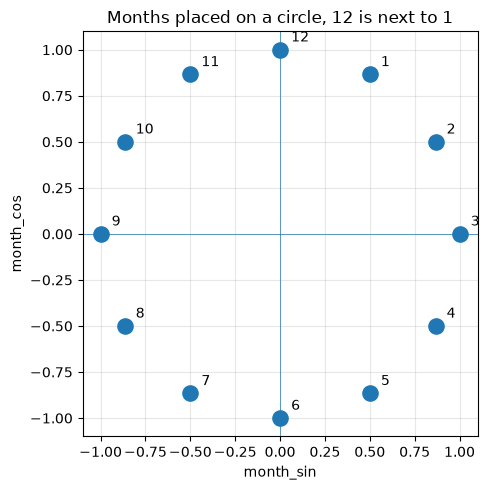

In [36]:
plt.figure(figsize=(5, 5))
plt.scatter(sin_values, cos_values, s=120, zorder=3)
for i, month in enumerate(months):
    plt.annotate(str(month), (sin_values[i], cos_values[i]),
                 textcoords='offset points', xytext=(8, 6))
plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.xlabel('month_sin')
plt.ylabel('month_cos')
plt.title('Months placed on a circle, 12 is next to 1')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
# 13. Rare Category Grouping

Before encoding a high cardinality column, a very effective preprocessing step is to merge all
rare categories into a single bucket called `Other`.

Benefits:

* fewer columns after one hot encoding
* rare categories usually have too few samples to learn anything reliable
* unseen categories at test time can be mapped to `Other` naturally

In [37]:
def group_rare_categories(series, threshold=0.05, other_label='Other'):
    frequencies = series.value_counts(normalize=True)
    frequent = frequencies[frequencies >= threshold].index
    return series.where(series.isin(frequent), other_label)


# A column where some categories are very rare
products = pd.Series(
    ['A'] * 50 + ['B'] * 30 + ['C'] * 12 + ['D'] * 3 + ['E'] * 3 + ['F'] * 2,
    name='product'
)

grouped = group_rare_categories(products, threshold=0.05)

print("Before grouping:", products.nunique(), "categories")
print(products.value_counts().to_dict())
print()
print("After grouping :", grouped.nunique(), "categories")
print(grouped.value_counts().to_dict())

Before grouping: 6 categories
{'A': 50, 'B': 30, 'C': 12, 'D': 3, 'E': 3, 'F': 2}

After grouping : 4 categories
{'A': 50, 'B': 30, 'C': 12, 'Other': 8}


---
# 14. Handling unseen categories at test time

This is the mistake that breaks the most student projects. The rule is simple:

> **Fit the encoder on the training data only. Never call `fit` on the test data.**

If you fit separately on train and test, the two datasets get different mappings and different
column counts, and the model receives garbage.

In [38]:
train = pd.DataFrame({'city': ['Delhi', 'Mumbai', 'Delhi', 'Chennai']})
test = pd.DataFrame({'city': ['Mumbai', 'Bengaluru']})   # Bengaluru is brand new

# The wrong way, using get_dummies separately on each set
train_wrong = pd.get_dummies(train['city'], dtype=int)
test_wrong = pd.get_dummies(test['city'], dtype=int)

print("Train columns:", list(train_wrong.columns))
print("Test columns :", list(test_wrong.columns))
print("Shapes match :", train_wrong.shape[1] == test_wrong.shape[1])
print()
print("The model was trained on 3 features but now receives 2 different ones, it will crash")

Train columns: ['Chennai', 'Delhi', 'Mumbai']
Test columns : ['Bengaluru', 'Mumbai']
Shapes match : False

The model was trained on 3 features but now receives 2 different ones, it will crash


In [39]:
# The right way, OneHotEncoder remembers the training categories
ohe_safe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int)
ohe_safe.fit(train[['city']])

train_ok = ohe_safe.transform(train[['city']])
test_ok = ohe_safe.transform(test[['city']])

print("Columns:", list(ohe_safe.get_feature_names_out()))
print()
print("Train encoded")
print(train_ok)
print()
print("Test encoded, Bengaluru becomes an all zero row instead of crashing")
print(test_ok)

Columns: ['city_Chennai', 'city_Delhi', 'city_Mumbai']

Train encoded
[[0 1 0]
 [0 0 1]
 [0 1 0]
 [1 0 0]]

Test encoded, Bengaluru becomes an all zero row instead of crashing
[[0 0 1]
 [0 0 0]]


`handle_unknown='ignore'` turns an unseen category into a row of all zeros.
`handle_unknown='infrequent_if_exist'` is another option that sends it to a learned
`infrequent` bucket instead.

---
# 15. Case study on a real dataset: Titanic

Now we apply everything to the **Titanic** dataset, one of the most widely used standard datasets
for teaching classification. It ships with seaborn, so no manual download is needed.

Goal: predict whether a passenger survived.

In [40]:
import seaborn as sns

try:
    titanic = sns.load_dataset('titanic')
    print("Loaded the Titanic dataset from seaborn")
except Exception as err:
    # Offline fallback so that the notebook still runs without internet
    print("Could not download, building a similar dataset locally. Reason:", err)
    n = 891
    rng = np.random.default_rng(42)
    titanic = pd.DataFrame({
        'survived': rng.integers(0, 2, n),
        'pclass': rng.choice([1, 2, 3], n, p=[0.24, 0.21, 0.55]),
        'sex': rng.choice(['male', 'female'], n, p=[0.65, 0.35]),
        'age': rng.normal(29, 14, n).clip(1, 80),
        'fare': rng.gamma(2, 16, n),
        'embarked': rng.choice(['S', 'C', 'Q'], n, p=[0.72, 0.19, 0.09]),
        'alone': rng.choice([True, False], n)
    })

print("Shape:", titanic.shape)
titanic.head()

Loaded the Titanic dataset from seaborn
Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [41]:
# Separating the columns by type, this is always the first step
# Anything that is not numeric is treated as categorical here
numeric_columns = titanic.select_dtypes(include=[np.number]).columns
categorical_columns = titanic.columns.difference(numeric_columns)

print("Categorical columns:", list(categorical_columns))
print()
print("Numeric columns    :", list(numeric_columns))

Categorical columns: ['adult_male', 'alive', 'alone', 'class', 'deck', 'embark_town', 'embarked', 'sex', 'who']

Numeric columns    : ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']


In [42]:
# Cardinality tells us which encoder is realistic for each column
cardinality = titanic[categorical_columns].nunique().sort_values()
print("Number of unique values per categorical column")
print(cardinality)

Number of unique values per categorical column
adult_male     2
alive          2
alone          2
sex            2
class          3
embark_town    3
embarked       3
who            3
deck           7
dtype: int64


In [43]:
# Selecting a clean, non redundant set of features
features = ['sex', 'embarked', 'pclass', 'age', 'fare', 'alone']
data = titanic[features + ['survived']].dropna(subset=['embarked']).copy()

data['alone'] = data['alone'].astype(str)
data['pclass'] = data['pclass'].astype(str)

X = data[features]
y = data['survived']

print("Final shape:", X.shape)
X.head()

Final shape: (889, 6)


,sex,embarked,pclass,age,fare,alone
0,male,S,3,22.0,7.2500,False
1,female,C,1,38.0,71.2833,False
2,female,S,3,26.0,7.9250,True
3,female,S,1,35.0,53.1000,False
4,male,S,3,35.0,8.0500,True


## 15.1 Building a proper pipeline with `ColumnTransformer`

In a real project you never encode columns one by one with loose code. You build a
`ColumnTransformer` that applies a different transformation to each group of columns,
and wrap the whole thing in a `Pipeline` together with the model.

The pipeline guarantees that

* encoders are fitted only on the training fold, so there is no leakage
* the identical transformation is applied at prediction time
* the entire object can be saved and deployed as one unit

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split

categorical_features = ['sex', 'embarked', 'pclass', 'alone']
numeric_features = ['age', 'fare']

# What to do with numeric columns, fill missing values then scale
numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

# What to do with categorical columns, fill missing values then one hot encode
categorical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])

full_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

full_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default

In [45]:
# Looking at what the preprocessor actually produced
transformed = preprocessor.fit_transform(X, y)
feature_names = preprocessor.get_feature_names_out()

print("Original number of columns :", X.shape[1])
print("Number of columns after encoding:", transformed.shape[1])
print()
pd.DataFrame(transformed, columns=feature_names).head().round(3)

Original number of columns : 6
Number of columns after encoding: 12



,numeric__age,numeric__fare,categorical__sex_female,categorical__sex_male,categorical__embarked_C,categorical__embarked_Q,categorical__embarked_S,categorical__pclass_1,categorical__pclass_2,categorical__pclass_3,categorical__alone_False,categorical__alone_True
0,-0.564,-0.500,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1,0.669,0.789,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-0.255,-0.487,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
3,0.438,0.423,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
4,0.438,-0.484,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


## 15.2 Comparing encoders on the same model

Now the interesting part. We keep the model fixed and change only the encoder, then measure
5 fold cross validated accuracy. This is how you decide which encoder suits your data.

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin


# scikit-learn has no built in frequency encoder, so we write our own.
# Inheriting from BaseEstimator and TransformerMixin is what makes it usable
# inside a Pipeline and a ColumnTransformer.
class FrequencyEncoder(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.maps_ = {column: X[column].value_counts(normalize=True) for column in X.columns}
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        out = pd.DataFrame(index=X.index)
        for column in X.columns:
            out[column] = X[column].map(self.maps_[column]).fillna(0.0)
        return out.values

    def get_feature_names_out(self, input_features=None):
        return np.array(['freq_' + str(c) for c in self.maps_.keys()])


def build_pipeline(encoder, model):
    categorical_part = Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', encoder)
    ])
    pre = ColumnTransformer([
        ('numeric', numeric_pipeline, numeric_features),
        ('categorical', categorical_part, categorical_features)
    ])
    return Pipeline([('preprocess', pre), ('model', model)])

In [47]:
encoders = {
    'Ordinal (label)': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
    'One Hot': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
    'One Hot drop first': OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False),
    'Target': TargetEncoder(random_state=42),
    'Frequency': FrequencyEncoder(),
}

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42)
}

results = []
for model_name, model in models.items():
    for encoder_name, encoder in encoders.items():
        pipeline = build_pipeline(encoder, model)
        scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
        results.append({
            'model': model_name,
            'encoder': encoder_name,
            'accuracy': scores.mean(),
            'std': scores.std()
        })

results_df = pd.DataFrame(results)
results_df.round(4)

c:\Users\Tavneet\Documents\ml_lab_practicals_csp_dc_305\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\Tavneet\Documents\ml_lab_practicals_csp_dc_305\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\Tavneet\Documents\ml_lab_practicals_csp_dc_305\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be remove

,model,encoder,accuracy,std
0,LogisticRegression,Ordinal (label),0.7840,0.0107
1,LogisticRegression,One Hot,0.7885,0.0188
2,LogisticRegression,One Hot drop first,0.7930,0.0173
3,LogisticRegression,Target,0.7885,0.0220
4,LogisticRegression,Frequency,0.8009,0.0191
5,RandomForest,Ordinal (label),0.8021,0.0325
6,RandomForest,One Hot,0.7976,0.0320
7,RandomForest,One Hot drop first,0.8020,0.0263
8,RandomForest,Target,0.8223,0.0218
9,RandomForest,Frequency,0.8077,0.0331


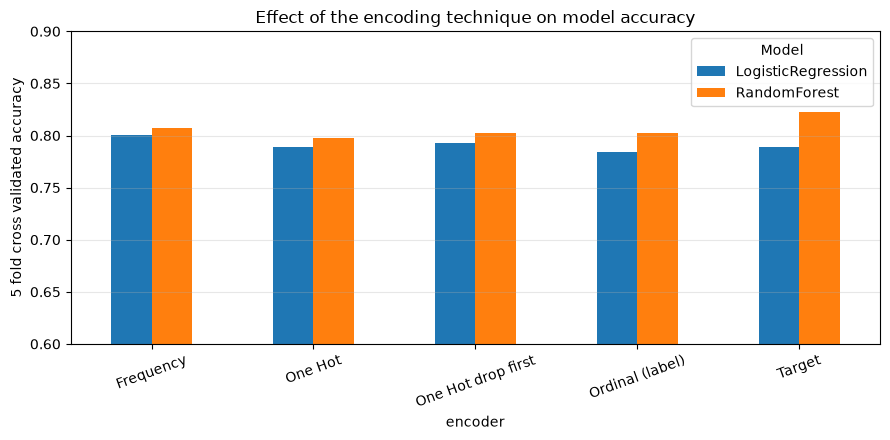

model,LogisticRegression,RandomForest
encoder,,
Frequency,0.8009,0.8077
One Hot,0.7885,0.7976
One Hot drop first,0.7930,0.8020
Ordinal (label),0.7840,0.8021
Target,0.7885,0.8223


In [48]:
pivot = results_df.pivot(index='encoder', columns='model', values='accuracy')

pivot.plot(kind='bar', figsize=(9, 4.5), rot=20)
plt.ylabel('5 fold cross validated accuracy')
plt.title('Effect of the encoding technique on model accuracy')
plt.ylim(0.6, 0.9)
plt.legend(title='Model')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

pivot.round(4)

### What to observe in these results

* **Logistic Regression** usually benefits from one hot encoding, because ordinal encoding forces
  a fake linear order on `embarked` and `pclass`
* **Random Forest** is far less sensitive. Trees can split repeatedly and recover the groups even
  from ordinal codes, so the difference between encoders is small
* **Target and Frequency encoding** produce only one column per feature instead of many, yet stay
  competitive, which is exactly why they are preferred when cardinality is high
* Differences of one or two percent on a dataset this small are within noise. Always look at the
  standard deviation across folds before declaring a winner

The lesson is that **the right encoder depends on the model and the data**, not on fashion.

## 15.3 Interpreting the coefficients

One underrated advantage of one hot encoding is interpretability. After training a logistic
regression you can read off the effect of each individual category.

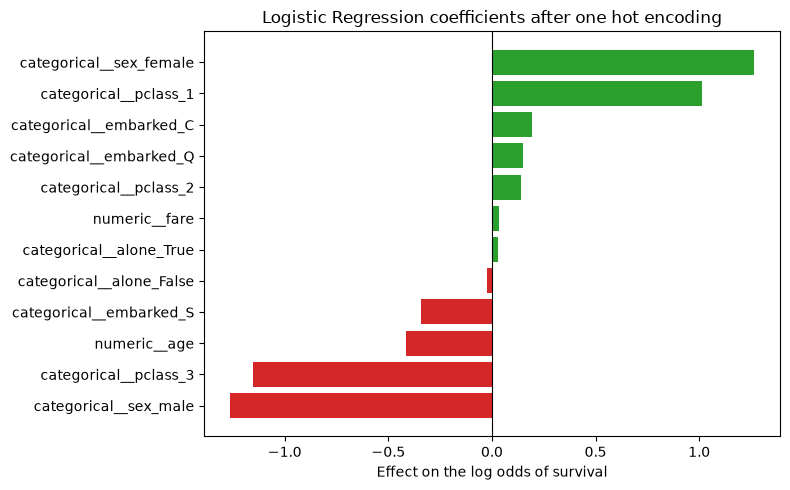

In [49]:
full_pipeline.fit(X, y)

names = full_pipeline.named_steps['preprocess'].get_feature_names_out()
coefficients = full_pipeline.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({'feature': names, 'coefficient': coefficients})
coef_df = coef_df.sort_values('coefficient')

plt.figure(figsize=(8, 5))
colors = ['tab:red' if c < 0 else 'tab:green' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression coefficients after one hot encoding')
plt.xlabel('Effect on the log odds of survival')
plt.tight_layout()
plt.show()

---
# 16. Comparison of all techniques

| Technique | Output columns | Best for | Watch out for |
|-----------|----------------|----------|---------------|
| **Label** | 1 | Target variable `y`, tree models | Invents a fake order in nominal data |
| **Ordinal** | 1 | Genuinely ordered categories | You must supply the correct order |
| **One Hot** | k | Nominal data, low cardinality, linear models | Column explosion, dummy variable trap |
| **Dummy (drop one)** | k - 1 | Linear and logistic regression | Choosing the baseline category |
| **Binary** | ceil(log2 k) | High cardinality nominal | Not interpretable, bits are shared |
| **Frequency / Count** | 1 | High cardinality, tree models | Equally frequent categories collide |
| **Target / Mean** | 1 | High cardinality, strong signal | Leakage and overfitting, needs smoothing |
| **Leave One Out** | 1 | Same as target encoding | Still leaky, fails on single row categories |
| **Hashing** | fixed n | Millions of categories, streaming data | Collisions, cannot be reversed |
| **Cyclic (sin, cos)** | 2 | Month, hour, weekday, angle | Only for genuinely circular features |

## A simple decision procedure

```
Is the column ordered?
        YES  ->  Ordinal Encoding with an explicit order list
        NO   ->  How many unique categories?

                 Less than about 15
                        Linear model     ->  One Hot with drop='first'
                        Tree model       ->  One Hot, or Ordinal for speed

                 Between 15 and 1000
                        Tree model       ->  Target Encoding (cross fitted) or Frequency
                        Linear model     ->  Group rare categories, then One Hot

                 More than 1000
                        ->  Hashing, Binary, or Target Encoding
                        ->  For deep learning, use a learned Embedding layer

Is the column circular (month, hour, angle)?
        ->  Cyclic sin and cos encoding
```

### A note on embeddings

In deep learning, high cardinality categories are usually handled by an **embedding layer**:
each category is mapped to a dense vector of, say, 16 numbers, and those numbers are **learned**
during training instead of being fixed by a rule. Word2Vec and the embedding layers inside
transformers are exactly this idea. You can think of an embedding as a one hot vector multiplied
by a learnable weight matrix, which is why one hot encoding is worth understanding well.

In [50]:
# One hot times a weight matrix is exactly a lookup, this is what an embedding layer does
one_hot_vector = np.array([0, 1, 0, 0])          # category number 1
embedding_matrix = np.array([
    [0.1, 0.9, 0.4],
    [0.7, 0.2, 0.5],
    [0.3, 0.3, 0.8],
    [0.6, 0.1, 0.2]
])

print("One hot times matrix :", one_hot_vector @ embedding_matrix)
print("Row 1 of the matrix  :", embedding_matrix[1])
print("They are identical, so an embedding is just a fast one hot lookup with learnable values")

One hot times matrix : [0.7 0.2 0.5]
Row 1 of the matrix  : [0.7 0.2 0.5]
They are identical, so an embedding is just a fast one hot lookup with learnable values


---
# 17. Common mistakes to avoid

1. **Fitting the encoder on the full dataset before splitting.**
   Always split first, then `fit` on train and only `transform` on test.

2. **Using `pd.get_dummies` separately on train and test.**
   The column sets will not match. Use `OneHotEncoder` inside a pipeline.

3. **Label encoding nominal features for a linear model.**
   This tells the model that `Mumbai > Delhi`, which is meaningless.

4. **One hot encoding a column with thousands of categories.**
   Use binary, hashing, target encoding, or group the rare values first.

5. **Target encoding without cross fitting.**
   Training accuracy near 100 percent and terrible test accuracy is the classic symptom.

6. **Forgetting the dummy variable trap in regression.**
   Drop one column for linear and logistic models.

7. **Treating month or hour as an ordinary number.**
   December and January end up maximally far apart. Use cyclic encoding.

8. **Encoding before handling missing values.**
   Decide first whether `NaN` is its own meaningful category or something to impute.

In [51]:
# A demonstration of mistake number 1, leakage through the encoder
sample = pd.DataFrame({
    'city': ['Delhi'] * 5 + ['Mumbai'] * 5 + ['Chennai'] * 5,
    'y': [1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0]
})

X_train, X_test, y_train, y_test = train_test_split(
    sample[['city']], sample['y'], test_size=0.4, random_state=0
)

# Correct order, fit on train only
enc_correct = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
enc_correct.fit(X_train)
print("Categories learned from the training set only:", enc_correct.categories_[0])
print("Test set is only transformed, never fitted, shape:", enc_correct.transform(X_test).shape)

Categories learned from the training set only: ['Chennai' 'Delhi' 'Mumbai']
Test set is only transformed, never fitted, shape: (6, 3)


---
# 18. Exercises

Try these on your own before the next class.

**Exercise 1.** Write a function `count_encode(series)` from scratch that returns the raw counts.
Verify it against `series.map(series.value_counts())`.

**Exercise 2.** The `deck` column of the Titanic dataset has many missing values.
Encode it in two ways, first by treating `NaN` as a category called `Unknown`, and second by
dropping the column. Compare the accuracy.

**Exercise 3.** Take the `education` column and encode it with (a) label encoding and
(b) correct ordinal encoding. Train a Logistic Regression on each and explain the difference
in the learned coefficient.

**Exercise 4.** Implement binary encoding for a column with 100 categories and confirm that it
produces exactly 7 columns.

**Exercise 5.** Build a column with 200 categories where only 5 are common.
Apply rare grouping at thresholds of 1, 2 and 5 percent, and plot how the number of one hot
columns changes.

**Exercise 6.** Implement leave one out target encoding, then deliberately implement the leaky
version. Train a Decision Tree on both and compare training accuracy with test accuracy.
Explain what you see.

**Exercise 7.** Encode the hour of the day, 0 to 23, using both plain integers and cyclic encoding.
Compute the distance between hour 23 and hour 0 in both schemes.

---

## Summary

* Models need numbers, so every categorical column must be encoded
* First identify the type: nominal, ordinal, binary, high cardinality or cyclic
* Nominal and low cardinality means one hot, ordinal means ordinal encoding with an explicit order
* High cardinality means binary, frequency, target or hashing encoding
* Always fit on the training data only, and always prefer a `Pipeline`
* Target encoding is the strongest and the most dangerous, use cross fitting and smoothing
* The choice of encoder interacts with the choice of model, so measure, do not guess